# Air Quality Assessment and AQI Forecasting Using Machine Learning
## Notebook 04: Redesigned Preprocessing Pipeline (Hourly Resolution)
---
### Objectives:
1. Load the original hourly meteorological dataset (`AQIdata.xlsx`) and the daily air quality dataset (`nehru-nagar, kanpur-air-quality (1).xlsx`).
2. Calculate the daily CPCB AQI on the original daily observations using validated logic (CO units divided by 1000, no capping).
3. Clean the hourly weather dataset (remove headers, deduplicate timestamps, drop index NaNs, cast types) preserving its original hourly timestamps.
4. Merge the calculated daily AQI onto the hourly weather observations (left join, maintaining original hourly timestamps without upsampling).
5. Perform time-series diagnostics (ADF stationarity test, ACF/PACF autocorrelation analysis).
6. Engineer meaningful forecasting features (lags, rolling stats, cyclical time transforms, trend dynamics) safely using shifted historical data to prevent leakage.
7. Construct exactly one future forecasting target column (`target_next_hour`).
8. Chronologically partition the dataset (80% train, 20% test) and scale features using a Standard Scaler fitted only on the training set.

In [25]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('Check: Libraries loaded.')

Check: Libraries loaded.


### Load Raw Datasets
We load the raw hourly weather dataset `AQIdata.xlsx` and the raw daily air quality pollutants dataset.

In [26]:
weather_paths = ['../data/raw/AQIdata.xlsx', 'data/raw/AQIdata.xlsx']
aqi_paths = ['../data/raw/nehru-nagar, kanpur-air-quality (1).xlsx', 'data/raw/nehru-nagar, kanpur-air-quality (1).xlsx']

df_weather_raw = None
for path in weather_paths:
    if os.path.exists(path):
        df_weather_raw = pd.read_excel(path, header=3)
        print(f'Check: Loaded raw weather shape: {df_weather_raw.shape}')
        break

df_aqi_raw = None
for path in aqi_paths:
    if os.path.exists(path):
        df_aqi_raw = pd.read_excel(path)
        print(f'Check: Loaded raw air quality shape: {df_aqi_raw.shape}')
        break

Check: Loaded raw weather shape: (105002, 10)
Check: Loaded raw air quality shape: (3977, 7)


### Calculate Daily CPCB AQI
We calculate the daily AQI value for each daily pollutant observation using the official CPCB linear interpolation formula. CO concentration values are divided by 1000 to convert from µg/m³ to mg/m³.

In [27]:
df_aqi = df_aqi_raw.copy()
df_aqi['Date'] = pd.to_datetime(df_aqi['Date'])
df_aqi['co'] = df_aqi['co'] / 1000.0  # Unit conversion to mg/m³

breakpoints = {
    'pm2.5': [(0, 30, 0, 50), (30, 60, 50, 100), (60, 90, 100, 200), (90, 120, 200, 300), (120, 250, 300, 400), (250, 380, 400, 500)],
    'pm10': [(0, 50, 0, 50), (50, 100, 50, 100), (100, 250, 100, 200), (250, 350, 200, 300), (350, 430, 300, 400), (430, 500, 400, 500)],
    'NO2': [(0, 40, 0, 50), (40, 80, 50, 100), (80, 180, 100, 200), (180, 280, 200, 300), (280, 400, 300, 400), (400, 800, 400, 500)],
    'SO2': [(0, 40, 0, 50), (40, 80, 50, 100), (80, 380, 100, 200), (380, 800, 200, 300), (800, 1600, 300, 400), (1600, 3200, 400, 500)],
    'co': [(0, 1, 0, 50), (1, 2, 50, 100), (2, 10, 100, 200), (10, 17, 200, 300), (17, 34, 300, 400), (34, 68, 400, 500)],
    'O3': [(0, 50, 0, 50), (50, 100, 50, 100), (100, 168, 100, 200), (168, 208, 200, 300), (208, 748, 300, 400), (748, 1000, 400, 500)]
}

def calculate_sub_index(val, pollutant):
    if pd.isna(val):
        return np.nan
    bp_list = breakpoints[pollutant]
    for c_lo, c_hi, i_lo, i_hi in bp_list:
        if c_lo <= val <= c_hi:
            return ((i_hi - i_lo) / (c_hi - c_lo)) * (val - c_lo) + i_lo
    c_lo, c_hi, i_lo, i_hi = bp_list[-1]
    return ((i_hi - i_lo) / (c_hi - c_lo)) * (val - c_lo) + i_lo

def calculate_aqi_row(row):
    sub_indices = {}
    for p in ['pm2.5', 'pm10', 'NO2', 'SO2', 'co', 'O3']:
        sub_indices[p] = calculate_sub_index(row[p], p)
    valid_indices = {k: v for k, v in sub_indices.items() if not pd.isna(v)}
    if len(valid_indices) < 3 or (('pm2.5' not in valid_indices) and ('pm10' not in valid_indices)):
        return np.nan
    return round(max(valid_indices.values()))

df_aqi['AQI'] = df_aqi.apply(calculate_aqi_row, axis=1)
df_aqi = df_aqi.dropna(subset=['AQI'])
print(f'Check: Daily AQI generated. Row count: {df_aqi.shape[0]}')

Check: Daily AQI generated. Row count: 3727


### Clean Hourly Weather Data
We clean secondary headers, convert the timestamps to Datetime objects, deduplicate observations, handle index NaNs, and cast meteorological features to numeric types.

In [28]:
df_weather = df_weather_raw.copy()
df_weather = df_weather[df_weather['time'] != 'time']
df_weather['time'] = pd.to_datetime(df_weather['time'])
df_weather = df_weather.dropna(subset=['time'])
df_weather = df_weather.drop_duplicates(subset=['time'])

cols_to_numeric = [c for c in df_weather.columns if c != 'time']
df_weather[cols_to_numeric] = df_weather[cols_to_numeric].apply(pd.to_numeric, errors='coerce')
print(f'Check: Cleaned hourly weather shape: {df_weather.shape}')

Check: Cleaned hourly weather shape: (100800, 10)


### Merge AQI onto Hourly Weather
We left-join the daily AQI values onto the hourly weather observations by date, keeping the original hourly timestamps exactly as they exist without any upsampling.

In [29]:
df_weather['Merge_Date'] = pd.DatetimeIndex(df_weather['time']).date
df_aqi['Merge_Date'] = pd.DatetimeIndex(df_aqi['Date']).date

df_merged = pd.merge(df_weather, df_aqi[['Merge_Date', 'AQI']], on='Merge_Date', how='left')
df_merged = df_merged.drop(columns=['Merge_Date'])
df_merged = df_merged.set_index('time').sort_index()

# Fill small alignment gaps using forward and backward fill
df_merged['AQI'] = df_merged['AQI'].ffill().bfill()
print(f'Check: Merged hourly dataset shape: {df_merged.shape}')
print(f'Gaps in AQI: {df_merged["AQI"].isnull().sum()}')

Check: Merged hourly dataset shape: (100800, 10)
Gaps in AQI: 0


### Exploratory Data Analysis & Visualizations

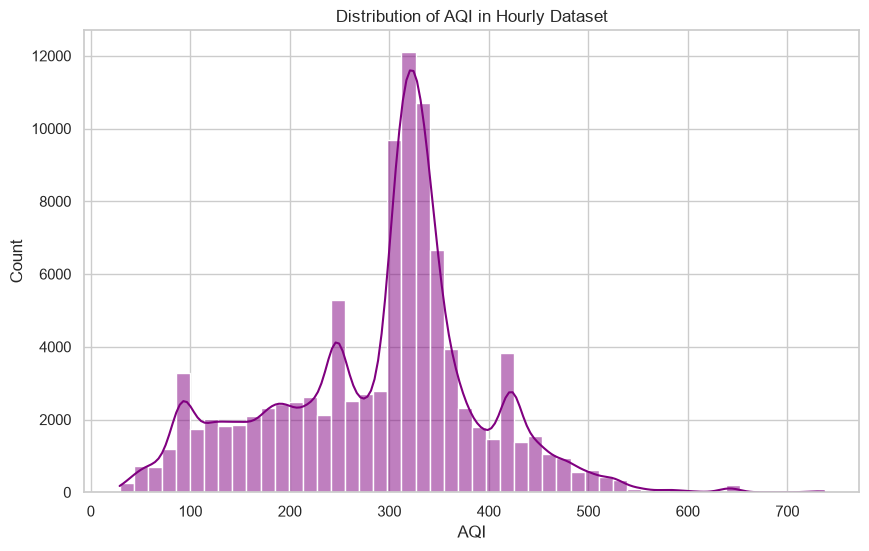

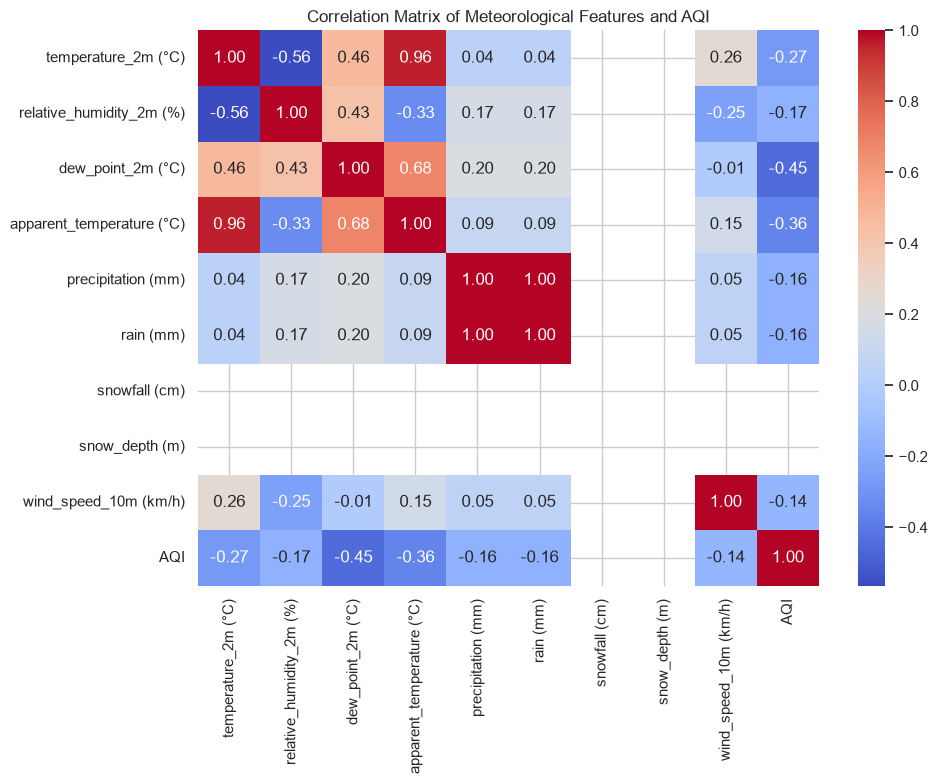

In [30]:
plt.figure(figsize=(10, 6))
sns.histplot(df_merged['AQI'], bins=50, kde=True, color='purple')
plt.title('Distribution of AQI in Hourly Dataset')
plt.xlabel('AQI')
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df_merged.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Meteorological Features and AQI')
plt.tight_layout()
plt.show()

### Time Series Diagnostics & Stationarity Audit

ADF Statistic: -4.5537
p-value      : 0.0002
Status: Series is stationary


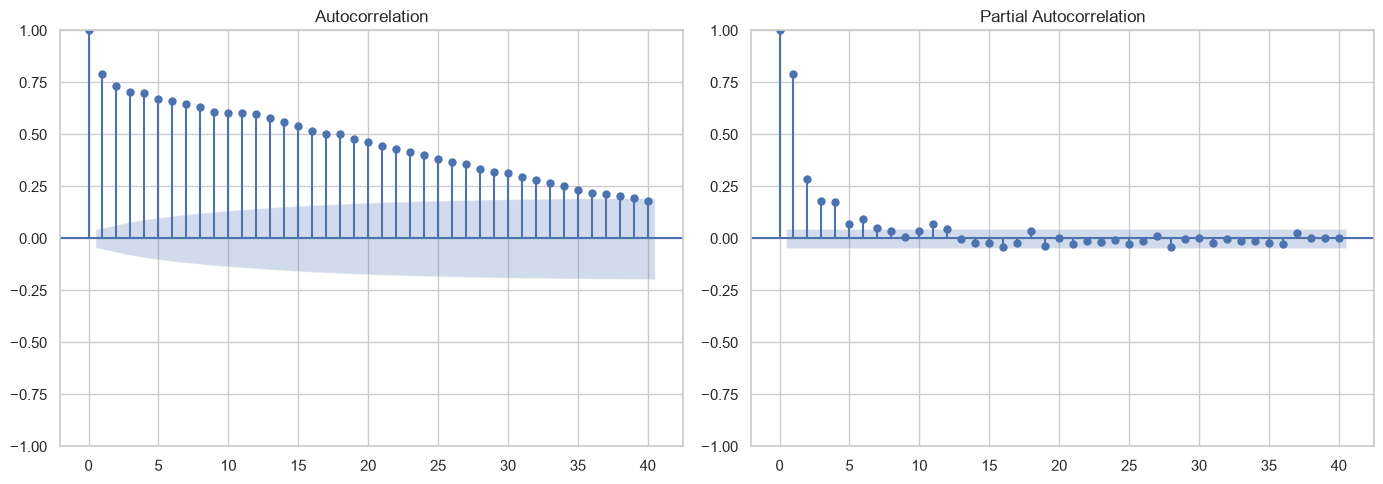

In [31]:
# Stationarity ADF Test on downsampled data to speed up calculation
adf_res = adfuller(df_merged['AQI'].iloc[::50])
print(f'ADF Statistic: {adf_res[0]:.4f}')
print(f'p-value      : {adf_res[1]:.4f}')
if adf_res[1] < 0.05:
    print('Status: Series is stationary')
else:
    print('Status: Series is non-stationary')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(df_merged['AQI'].iloc[::50], lags=40, ax=axes[0])
plot_pacf(df_merged['AQI'].iloc[::50], lags=40, ax=axes[1])
plt.tight_layout()
plt.show()

### Feature Engineering
We engineer temporal features, cyclical wave coordinates, autoregressive lags, and rolling window trends strictly using past data (`.shift(1)`) to avoid target leakage.

In [32]:
times = pd.DatetimeIndex(df_merged.index)
df_merged['Hour'] = times.hour
df_merged['DayOfWeek'] = times.dayofweek
df_merged['Month'] = times.month

def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4]: return 'Spring'
    elif month in [5, 6]: return 'Summer'
    elif month in [7, 8, 9]: return 'Monsoon'
    return 'Autumn'
df_merged['Season'] = df_merged['Month'].apply(get_season)
df_merged = pd.get_dummies(df_merged, columns=['Season'], prefix='season', dtype=int)

for s in ['season_Winter', 'season_Spring', 'season_Summer', 'season_Monsoon', 'season_Autumn']:
    if s not in df_merged.columns:
        df_merged[s] = 0

df_merged['Hour_sin'] = np.sin(2 * np.pi * df_merged['Hour'] / 24.0)
df_merged['Hour_cos'] = np.cos(2 * np.pi * df_merged['Hour'] / 24.0)
df_merged['Month_sin'] = np.sin(2 * np.pi * df_merged['Month'] / 12.0)
df_merged['Month_cos'] = np.cos(2 * np.pi * df_merged['Month'] / 12.0)

# 3. Lags (Shifted by >= 1 step to prevent same-day leakage)
for lag in [1, 2, 24]:
    df_merged[f'aqi_lag_{lag}'] = df_merged['AQI'].shift(lag)

# 4. Rolling Features (using shift(1) to prevent leakage)
for r in [3, 6, 12, 24]:
    df_merged[f'aqi_roll_mean_{r}'] = df_merged['AQI'].shift(1).rolling(window=r).mean()
    df_merged[f'aqi_roll_std_{r}'] = df_merged['AQI'].shift(1).rolling(window=r).std()
    df_merged[f'aqi_roll_min_{r}'] = df_merged['AQI'].shift(1).rolling(window=r).min()
    df_merged[f'aqi_roll_max_{r}'] = df_merged['AQI'].shift(1).rolling(window=r).max()

# 5. Trend Features
df_merged['aqi_diff'] = df_merged['AQI'].shift(1).diff()
df_merged['aqi_pct_change'] = df_merged['AQI'].shift(1).pct_change()

df_merged = df_merged.bfill().ffill()
print('Check: Feature engineering completed.')

Check: Feature engineering completed.


### Target Creation (Only One Target)
We create a single forecasting target: `target_next_hour` by shifting AQI by -1, and drop the single boundary NaN row at the end.

In [33]:
df_merged['target_next_hour'] = df_merged['AQI'].shift(-1)
df_merged = df_merged.dropna(subset=['target_next_hour'])
print(f'Check: Target column created. Dataset shape: {df_merged.shape}')

Check: Target column created. Dataset shape: (100799, 44)


### Chronological Split
We split the dataset chronologically (80% train, 20% test).

In [34]:
split_idx = int(len(df_merged) * 0.8)
df_train = df_merged.iloc[:split_idx].copy()
df_test = df_merged.iloc[split_idx:].copy()

print(f'Train partition: {df_train.shape[0]} rows ({df_train.index.min()} to {df_train.index.max()})')
print(f'Test partition : {df_test.shape[0]} rows ({df_test.index.min()} to {df_test.index.max()})')

Train partition: 80639 rows (2015-01-01 00:00:00 to 2024-03-13 22:00:00)
Test partition : 20160 rows (2024-03-13 23:00:00 to 2026-07-01 22:00:00)


### Leakage-Free Scaling
The scaler is fit only on the training set features and used to standardize both partitions.

In [35]:
exclude_cols = ['target_next_hour']
scale_cols = [c for c in df_train.columns if c not in exclude_cols]

scaler = StandardScaler()
df_train[scale_cols] = scaler.fit_transform(df_train[scale_cols])
df_test[scale_cols] = scaler.transform(df_test[scale_cols])

print('Check: Scaling completed successfully without data leakage.')

Check: Scaling completed successfully without data leakage.


### Save Preprocessed Datasets & Scaler

In [36]:
base_dir = '..' if os.path.exists('../data') else '.'
processed_dir = os.path.join(base_dir, 'data/processed')
models_dir = os.path.join(base_dir, 'models')

os.makedirs(processed_dir, exist_ok=True)
os.makedirs(models_dir, exist_ok=True)

df_train.to_csv(os.path.join(processed_dir, 'AQIdata_train_processed.csv'), index=False)
df_test.to_csv(os.path.join(processed_dir, 'AQIdata_test_processed.csv'), index=False)
joblib.dump(scaler, os.path.join(models_dir, 'forecasting_scaler.pkl'))

print('✓ Cleaned and scaled data partitions successfully saved.')

✓ Cleaned and scaled data partitions successfully saved.
